In [47]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from pyspark.sql.functions import col, count, isnan, when
from pyspark.sql.functions import col
from pyspark.sql.functions import to_date
import math
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [48]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AppleStockPricenew") \
    .getOrCreate()

df = spark.read.csv("hdfs:///user1/Apple1.csv", header=True, inferSchema=True)
df.show(5)


+-------------------+------------------+------------------+------------------+------------------+---------+---------+------------+
|               Date|              Open|              High|               Low|             Close|   Volume|Dividends|Stock Splits|
+-------------------+------------------+------------------+------------------+------------------+---------+---------+------------+
|2021-01-04 05:00:00|130.10136410422703|130.18905617994074|123.51444475784658|126.09659576416016|143301900|      0.0|         0.0|
|2021-01-05 05:00:00|125.58986443353002|128.36689819774932|125.14163585794874|127.65557861328125| 97664900|      0.0|         0.0|
|2021-01-06 05:00:00|124.44986199518105|127.69460255545032|123.14416745080455|123.35853576660156|155088000|      0.0|         0.0|
|2021-01-07 05:00:00|125.07346559980046|128.25974454135618|124.58626762143851|127.56791687011719|109578200|      0.0|         0.0|
|2021-01-08 05:00:00| 129.0392208425577|129.23411188523488|126.89555318600054|128.6

In [49]:
df.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)



In [50]:

# Separate numeric and non-numeric columns
numeric_cols = [c[0] for c in df.dtypes if c[1] in ('int', 'double', 'float')]
non_numeric_cols = [c[0] for c in df.dtypes if c[1] not in ('int', 'double', 'float')]

# Count nulls for numeric columns (check for NaN as well)
numeric_nulls = df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in numeric_cols])

# Count nulls for non-numeric columns (only check for NULL)
non_numeric_nulls = df.select([count(when(col(c).isNull(), c)).alias(c) for c in non_numeric_cols])

# Show results
print("Numeric column nulls:")
numeric_nulls.show()
print("Non-numeric column nulls:")
non_numeric_nulls.show()


Numeric column nulls:
+----+----+---+-----+------+---------+------------+
|Open|High|Low|Close|Volume|Dividends|Stock Splits|
+----+----+---+-----+------+---------+------------+
|   0|   0|  0|    0|     0|        0|           0|
+----+----+---+-----+------+---------+------------+

Non-numeric column nulls:
+----+
|Date|
+----+
|   0|
+----+



In [51]:
import time

# Relevant columns

columns = ["Date", "Close", "Open", "High", "Low", "Volume"]


# 1. DataFrame version with timing
start_df = time.time()

df_clean = df.select(columns).na.drop()
df_clean = df_clean.withColumn("Date", to_date(col("Date")))
df_clean = df_clean.orderBy("Date")

# Compute additional features
df_clean = df_clean.withColumn("daily_return", (col("Close") - col("Open")) / col("Open"))
df_clean = df_clean.withColumn("daily_volatility", (col("High") - col("Low")) / col("Open"))

# Convert to pandas for ML later
df_pd = df_clean.toPandas()

end_df = time.time()
print("DataFrame preprocessing time:", round(end_df - start_df, 4), "seconds")
df_pd.head()


DataFrame preprocessing time: 0.5742 seconds


,Date,Close,Open,High,Low,Volume,daily_return,daily_volatility
0,2021-01-04,126.096596,130.101364,130.189056,123.514445,143301900,-0.030782,0.051303
1,2021-01-05,127.655579,125.589864,128.366898,125.141636,97664900,0.016448,0.025681
2,2021-01-06,123.358536,124.449862,127.694603,123.144167,155088000,-0.008769,0.036564
3,2021-01-07,127.567917,125.073466,128.259745,124.586268,109578200,0.019944,0.029371
4,2021-01-08,128.668961,129.039221,129.234112,126.895553,105158200,-0.002869,0.018123


In [52]:
start_rdd = time.time()

# Select columns and drop nulls
rdd = df.select(columns).na.drop().rdd

# Map to proper types (Date already datetime from Spark, numeric columns to float)
rdd_clean = rdd.map(lambda row: (
    row['Date'],           # datetime
    float(row['Open']),
    float(row['High']),
    float(row['Low']),
    float(row['Close']),
    float(row['Volume'])
))

# Sort by Date
rdd_clean = rdd_clean.sortBy(lambda x: x[0])

# Compute additional features
rdd_features = rdd_clean.map(lambda x: (
    x[0], x[1], x[2], x[3], x[4], x[5],
    (x[4] - x[1]) / x[1],  # daily_return
    (x[2] - x[3]) / x[1]   # daily_volatility
))

# Convert to Pandas
df_rdd = pd.DataFrame(
    rdd_features.collect(),
    columns=[
        "Date", "Open", "High", "Low", "Close", "Volume",
        "daily_return", "daily_volatility"
    ]
)

end_rdd = time.time()
print("RDD preprocessing time:", round(end_rdd - start_rdd, 4), "seconds")
#df_rdd.head()



RDD preprocessing time: 0.5102 seconds


25/10/12 03:41:27 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 3592104 ms exceeds timeout 120000 ms
25/10/12 10:00:59 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.rpc.RpcTimeoutException: Futures timed out after [10000 milliseconds]. This timeout is controlled by spark.executor.heartbeatInterval
	at org.apache.spark.rpc.RpcTimeout.org$apache$spark$rpc$RpcTimeout$$createRpcTimeoutException(RpcTimeout.scala:47)
	at org.apache.spark.rpc.RpcTimeout$$anonfun$addMessageIfTimeout$1.applyOrElse(RpcTimeout.scala:62)
	at org.apache.spark.rpc.RpcTimeout$$anonfun$addMessageIfTimeout$1.applyOrElse(RpcTimeout.scala:58)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:38)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:76)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1236)
	at org.apache.spark.

25/10/12 10:01:01 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

	at scala.concurrent.impl.CallbackRunnable.run(Promise.scala:64)
	at scala.concurrent.BatchingExecutor$Batch.processBatch$1(BatchingExecutor.scala:67)
	at scala.concurrent.BatchingExecutor$Batch.$anonfun$run$1(BatchingExecutor.scala:82)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at scala.concurrent.BlockContext$.withBlockContext(BlockContext.scala:85)
	at scala.concurrent.BatchingExecutor$Batch.run(BatchingExecutor.scala:59)
	at scala.concurrent.Future$InternalCallbackExecutor$.unbatchedExecute(Future.scala:875)
	at scala.concurrent.BatchingExecutor.execute(BatchingExecutor.scala:110)
	at scala.concurrent.BatchingExecutor.execute$(BatchingExecutor.scala:107)
	at scala.concurrent.Future$InternalCallbackExecutor$.execute(Future.scala:873)
	at scala.concurrent.impl.CallbackRunnable.executeWithValue(Promise.scala:72)
	at scala.concurrent.impl.Promise$DefaultPromise.$anonfun$tryComplete$1(Promise.scala:288)
	at scala.concurrent.impl.Promise$DefaultPromise.$a

25/10/12 10:01:02 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

...

25/10/12 10:01:04 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

25/10/12 10:01:04 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

	at scala.concurrent.impl.Promise.transformWith$(Promise.scala:38)
	at scala.concurrent.impl.Promise$DefaultPromise.transformWith(Promise.scala:187)
	at scala.concurrent.Future.flatMap(Future.scala:306)
	at scala.concurrent.Future.flatMap$(Future.scala:306)
	at scala.concurrent.impl.Promise$DefaultPromise.flatMap(Promise.scala:187)
	at org.apache.spark.rpc.netty.NettyRpcEnv.asyncSetupEndpointRefByURI(NettyRpcEnv.scala:150)
	... 17 more
25/10/12 10:01:05 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManage

	at org.apache.spark.rpc.netty.LocalNettyRpcCallContext.send(NettyRpcCallContext.scala:50)
	at org.apache.spark.rpc.netty.NettyRpcCallContext.reply(NettyRpcCallContext.scala:32)
	at org.apache.spark.rpc.netty.RpcEndpointVerifier$$anonfun$receiveAndReply$1.applyOrElse(RpcEndpointVerifier.scala:31)
	... 8 more
25/10/12 10:01:05 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.st

25/10/12 10:01:05 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1240)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:296)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

In [5]:


# Select useful columns and drop/remove missing values (if any)
df_clean = df.select("Date", "Close", "Open", "High", "Low", "Volume").na.drop()

# Convert Date to proper format
df_clean = df_clean.withColumn("Date", to_date(col("Date")))
df_clean.schema["Date"].dataType


DateType()

In [17]:
df_clean.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Close: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- daily_return: double (nullable = true)
 |-- daily_volatility: double (nullable = true)



In [7]:
# Sort by date
df_clean = df_clean.orderBy("Date")

In [8]:
#Converting to pandas dataframe
df_pd = df_clean.toPandas()




(1193, 6)

In [18]:
df_pd.shape

(1193, 8)

In [9]:
df_clean.show(5)

+----------+------------------+------------------+------------------+------------------+---------+
|      Date|             Close|              Open|              High|               Low|   Volume|
+----------+------------------+------------------+------------------+------------------+---------+
|2021-01-04|126.09659576416016|130.10136410422703|130.18905617994074|123.51444475784658|143301900|
|2021-01-05|127.65557861328125|125.58986443353002|128.36689819774932|125.14163585794874| 97664900|
|2021-01-06|123.35853576660156|124.44986199518105|127.69460255545032|123.14416745080455|155088000|
|2021-01-07|127.56791687011719|125.07346559980046|128.25974454135618|124.58626762143851|109578200|
|2021-01-08|128.66896057128906| 129.0392208425577|129.23411188523488|126.89555318600054|105158200|
+----------+------------------+------------------+------------------+------------------+---------+
only showing top 5 rows



<AxesSubplot: title={'center': 'Apple Closing Prices (2019–2025)'}, xlabel='Date'>

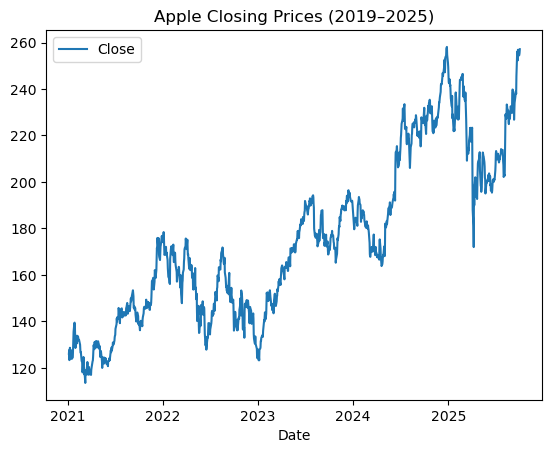

In [10]:
df_pd.plot(x='Date', y='Close', title='Apple Closing Prices (2019–2025)')

In [39]:
#EDA

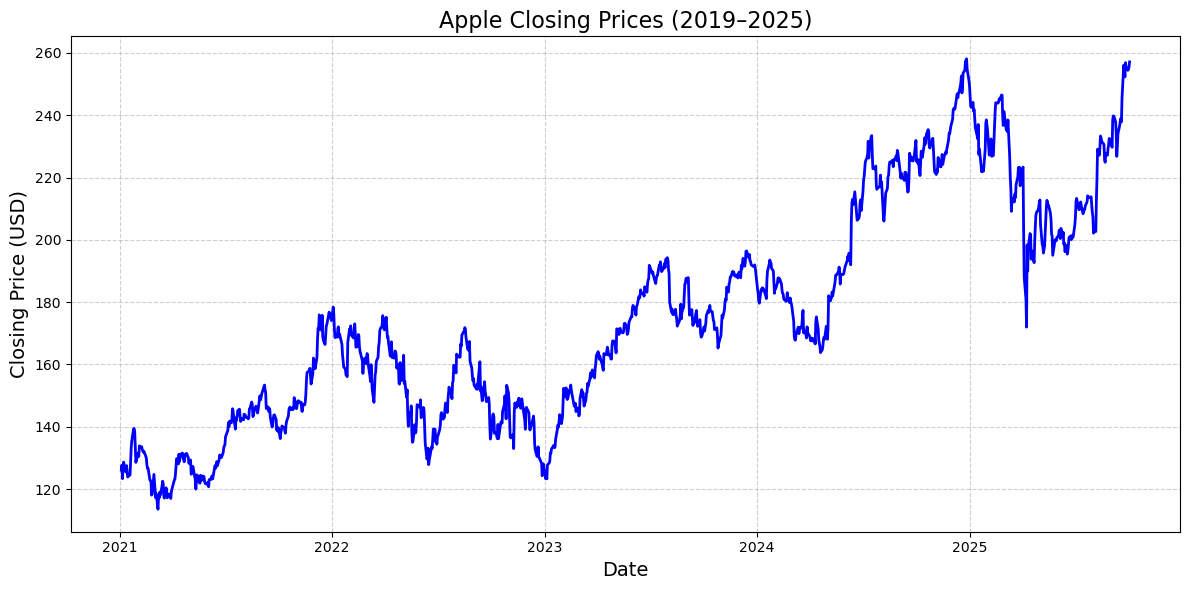

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert Date column to datetime (if not already)
#df_pd['Date'] = pd.to_datetime(df_pd['Date'])

# Plot Apple closing prices
plt.figure(figsize=(12,6))
plt.plot(df_pd['Date'], df_pd['Close'], color='blue', linewidth=2)

plt.title('Apple Closing Prices (2019–2025)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Closing Price (USD)', fontsize=14)

# Format date axis
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [13]:
print(df_pd.describe())


             Close         Open         High          Low        Volume
count  1193.000000  1193.000000  1193.000000  1193.000000  1.193000e+03
mean    175.075184   174.890360   176.809007   173.151672  7.109015e+07
std      35.401375    35.328140    35.580185    35.120768  2.990392e+07
min     113.550140   116.155679   117.492580   113.403761  2.323470e+07
25%     145.759430   145.553877   147.022337   144.124563  4.951470e+07
50%     170.665619   170.212802   171.945817   168.785230  6.458890e+07
75%     200.852051   201.201646   203.209377   199.233893  8.592800e+07
max     258.103729   257.276679   259.179926   256.718662  3.186799e+08


In [14]:
print(df_pd.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1193 non-null   object 
 1   Close   1193 non-null   float64
 2   Open    1193 non-null   float64
 3   High    1193 non-null   float64
 4   Low     1193 non-null   float64
 5   Volume  1193 non-null   int32  
dtypes: float64(4), int32(1), object(1)
memory usage: 51.4+ KB
None


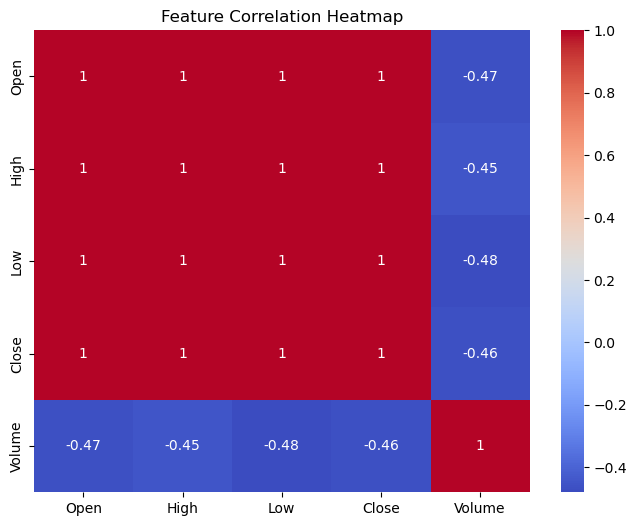

In [15]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_pd[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


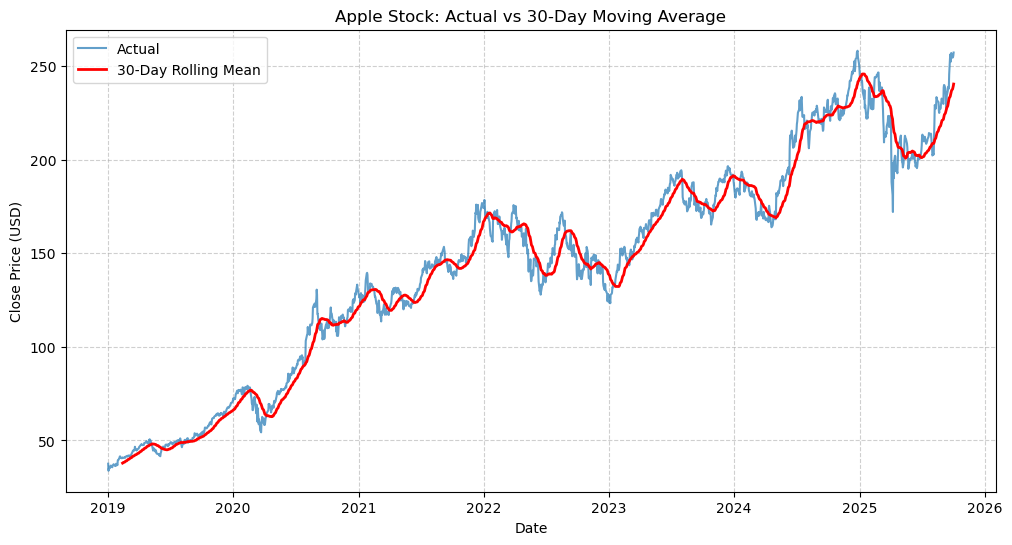

In [16]:
df_pd['Rolling_Mean_30'] = df_pd['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df_pd['Date'], df_pd['Close'], label='Actual', alpha=0.7)
plt.plot(df_pd['Date'], df_pd['Rolling_Mean_30'], label='30-Day Rolling Mean', color='red', linewidth=2)
plt.title('Apple Stock: Actual vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


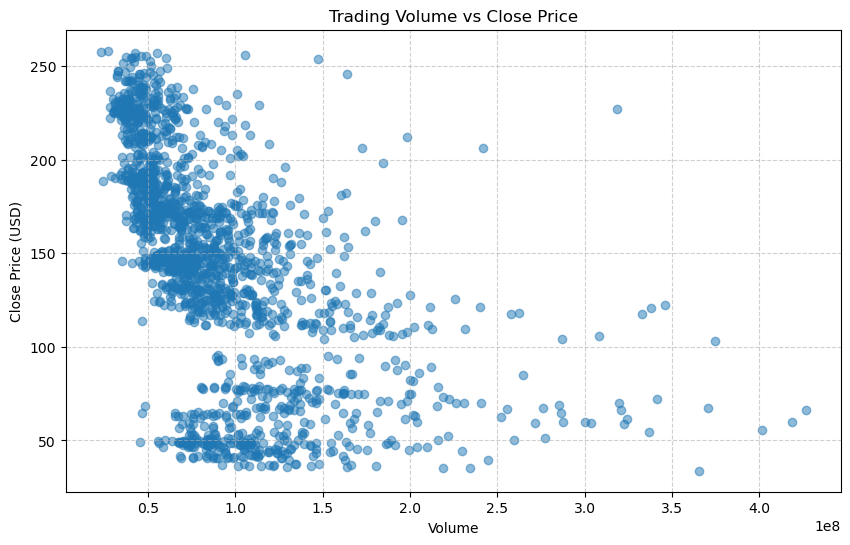

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(df_pd['Volume'], df_pd['Close'], alpha=0.5)
plt.title('Trading Volume vs Close Price')
plt.xlabel('Volume')
plt.ylabel('Close Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


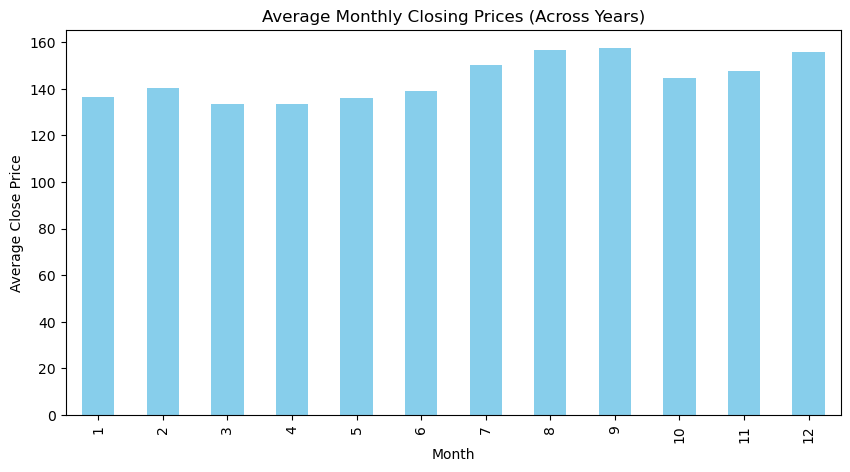

In [18]:
df_pd['Date'] = pd.to_datetime(df_pd['Date'])
df_pd['Month'] = df_pd['Date'].dt.month
df_pd['Year'] = df_pd['Date'].dt.year

monthly_avg = df_pd.groupby('Month')['Close'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title('Average Monthly Closing Prices (Across Years)')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.show()


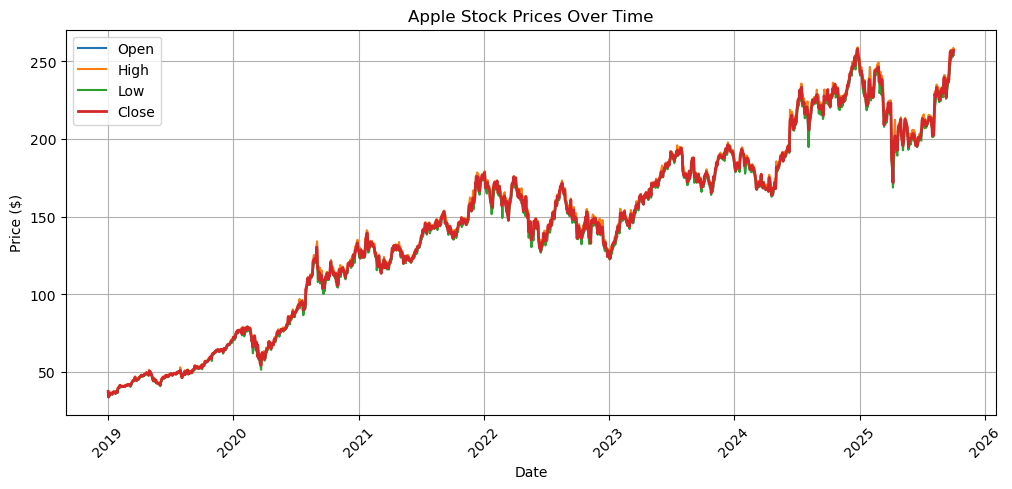

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df_pd['Date'], df_pd['Open'], label='Open')
plt.plot(df_pd['Date'], df_pd['High'], label='High')
plt.plot(df_pd['Date'], df_pd['Low'], label='Low')
plt.plot(df_pd['Date'], df_pd['Close'], label='Close', linewidth=2)
plt.title('Apple Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


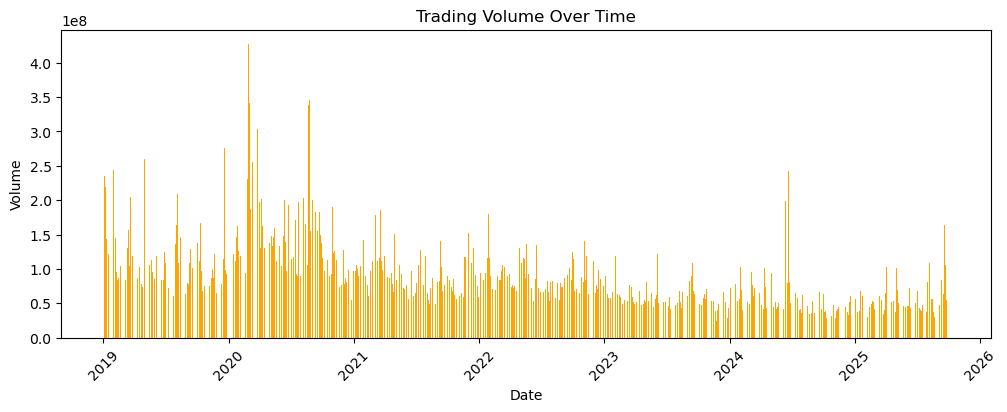

In [20]:
plt.figure(figsize=(12,4))
plt.bar(df_pd['Date'], df_pd['Volume'], color='orange')
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.show()


In [21]:
from sklearn.preprocessing import MinMaxScaler
import math

# Select features for modelling
data = df_pd[['Close']].values
training_data_len= math.ceil(len(data)* .8)


In [22]:
training_data_len

1359

In [23]:
# Scale values between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
#scaled data
data = scaler.fit_transform(data)


In [24]:
train_data= data[0:training_data_len, :]

In [25]:
x_train=[]
y_train=[]

In [26]:
for i in range(40, len(train_data)):
    x_train.append(train_data[i-40:i, 0])
    y_train.append(train_data[i, 0])

In [27]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [28]:
x_train= np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))

In [29]:
x_train.shape

(1319, 40, 1)

In [30]:
y_train.shape

(1319,)

In [31]:


X_train=torch.tensor(x_train, dtype=torch.float32)
#y_train=torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

X_train.shape
#train_dataset = TensorDataset(X_train, y_train)
#train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False

torch.Size([1319, 40, 1])

In [32]:
y_train=torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

In [33]:
y_train.shape

torch.Size([1319, 1])

In [34]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)  # no shuffle for time series

In [35]:


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [36]:
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss=0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss+= loss.item()
    print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}")


Epoch[1/50], Loss: 0.008401
Epoch[2/50], Loss: 0.094803
Epoch[3/50], Loss: 0.057409
Epoch[4/50], Loss: 0.041206
Epoch[5/50], Loss: 0.024141
Epoch[6/50], Loss: 0.014589
Epoch[7/50], Loss: 0.005371
Epoch[8/50], Loss: 0.001248
Epoch[9/50], Loss: 0.000701
Epoch[10/50], Loss: 0.001350
Epoch[11/50], Loss: 0.000570
Epoch[12/50], Loss: 0.000572
Epoch[13/50], Loss: 0.000579
Epoch[14/50], Loss: 0.000715
Epoch[15/50], Loss: 0.000473
Epoch[16/50], Loss: 0.000575
Epoch[17/50], Loss: 0.000464
Epoch[18/50], Loss: 0.000498
Epoch[19/50], Loss: 0.000445
Epoch[20/50], Loss: 0.000461
Epoch[21/50], Loss: 0.000435
Epoch[22/50], Loss: 0.000444
Epoch[23/50], Loss: 0.000436
Epoch[24/50], Loss: 0.000440
Epoch[25/50], Loss: 0.000440
Epoch[26/50], Loss: 0.000443
Epoch[27/50], Loss: 0.000447
Epoch[28/50], Loss: 0.000452
Epoch[29/50], Loss: 0.000458
Epoch[30/50], Loss: 0.000465
Epoch[31/50], Loss: 0.000473
Epoch[32/50], Loss: 0.000481
Epoch[33/50], Loss: 0.000489
Epoch[34/50], Loss: 0.000498
Epoch[35/50], Loss: 0.0

In [37]:
# Evaluate on train set
model.eval()
train_preds = []
with torch.no_grad():   #disables gradient tracking
    for X_batch, _ in train_loader:
        output = model(X_batch)
        train_preds.append(output.detach().numpy()) #combine batches into one array

train_preds = np.vstack(train_preds)

In [38]:
train_preds_rescaled = scaler.inverse_transform(train_preds)
y_train_rescaled = scaler.inverse_transform(y_train.numpy())


In [47]:
# Metrics


train_rmse = np.sqrt(mean_squared_error(y_train_rescaled, train_preds_rescaled))
train_mae = mean_absolute_error(y_train_rescaled, train_preds_rescaled)
train_r2 = r2_score(y_train_rescaled, train_preds_rescaled)

print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")

Train RMSE: 8.8605, MAE: 7.4257, R²: 0.9620


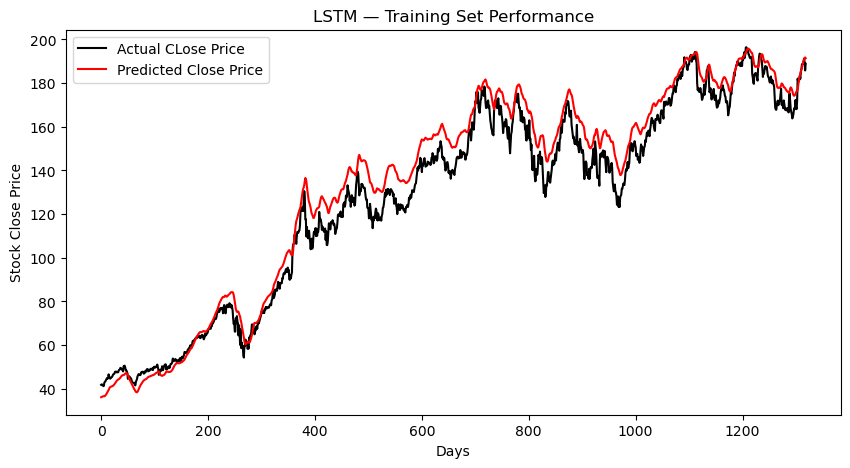

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_train_rescaled, label='Actual CLose Price', color='black')
plt.plot(train_preds_rescaled, label='Predicted Close Price', color='red')
plt.title('LSTM — Training Set Performance')
plt.xlabel('Days')
plt.ylabel('Stock Close Price')
plt.legend()
plt.show()

In [49]:
# Create test data
test_data = data[training_data_len - 40:, :]  # include last 30 train samples

x_test = []
y_test = []

for i in range(40, len(test_data)):
    x_test.append(test_data[i-40:i, 0])  # previous 40 days
    y_test.append(test_data[i, 0])       # current day

# Convert to arrays
x_test = np.array(x_test)
y_test = np.array(y_test)

# Reshape x_test to (samples, timesteps, features)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


x_test: (339, 40, 1)
y_test: (339,)


In [50]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_test=torch.tensor(x_test, dtype=torch.float32)
y_test=torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

X_test.shape

torch.Size([339, 40, 1])

In [51]:
y_test.shape

torch.Size([339, 1])

In [52]:
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # no shuffle for time series

In [53]:
# Evaluate on test set

model.eval()  # put model in evaluation mode
preds = []

with torch.no_grad():  # no gradient computation
    for X_batch, _ in test_loader:
        output = model(X_batch)
        preds.append(output.detach().numpy())

# Combine batch predictions
preds = np.vstack(preds)  # shape -> (num_test_samples, 1)


In [54]:
# Rescale predictions to original range
preds_rescaled = scaler.inverse_transform(preds)  # already 1 column

# Rescale original y_test for comparison
y_test_rescaled = scaler.inverse_transform(y_test.numpy())

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure predictions and true values are 1D
y_true = y_test_rescaled.flatten()
y_pred = preds_rescaled.flatten()

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE
mae = mean_absolute_error(y_true, y_pred)

# R² Score
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


RMSE: 12.4151
MAE: 10.3738
R² Score: 0.4171


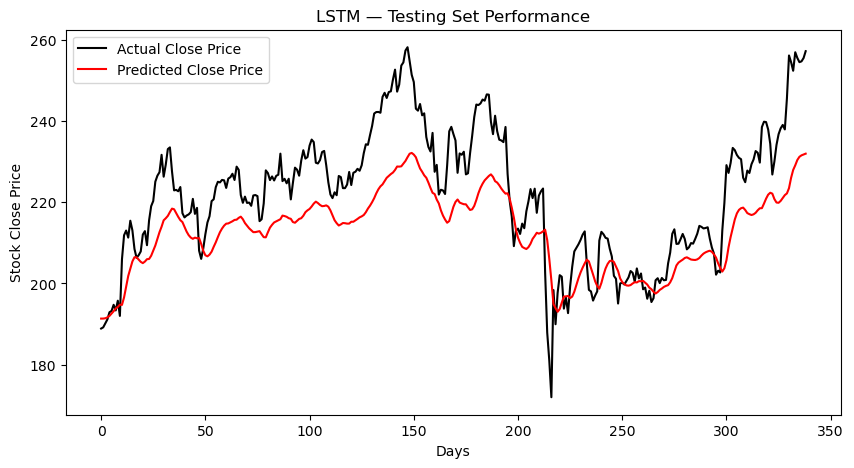

In [56]:
#Plot predictions vs real values

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label='Actual Close Price', color='black')
plt.plot(preds_rescaled, label='Predicted Close Price', color='red')
plt.title('LSTM — Testing Set Performance')
plt.xlabel('Days')
plt.ylabel('Stock Close Price')
plt.legend()
plt.show()


In [ ]:
#code with validation n hyperparameter tuning

In [23]:
data = df_pd['Close'].values
timestep = 30  # your time step


In [24]:
# Train-test split
train_size = int(len(data) * 0.8)
train_data_raw = data[:train_size]
test_data_raw = data[train_size:]

# Scale
scaler = MinMaxScaler(feature_range=(0,1))
train_data_scaled = scaler.fit_transform(train_data_raw.reshape(-1,1))
test_data_scaled = scaler.transform(test_data_raw.reshape(-1,1))

In [25]:
val_size = int(len(train_data_scaled) * 0.1)
train_data_final = train_data_scaled[:-val_size]
val_data = train_data_scaled[-val_size:]

In [26]:
# Sequence creation
def create_sequences(data, time_step):
    X, Y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        Y.append(data[i+time_step])
    return np.array(X), np.array(Y)

X_train_1, Y_train = create_sequences(train_data_final, timestep)
X_val_1, Y_val = create_sequences(val_data, timestep)
X_test_1, Y_test = create_sequences(test_data_scaled, timestep)

# Reshape for LSTM/GRU input
X_train = X_train_1.reshape(X_train_1.shape[0], X_train_1.shape[1], 1)
X_val = X_val_1.reshape(X_val_1.shape[0], X_val_1.shape[1], 1)
X_test = X_test_1.reshape(X_test_1.shape[0], X_test_1.shape[1], 1)

In [27]:
# Convert to tensors
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).float()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).float()

In [28]:
# Dataloaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_tensor, Y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, Y_test_tensor), batch_size=batch_size, shuffle=False)


In [29]:
import torch
import torch.nn as nn

# -----------------------------
# LSTM Model
# -----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(LSTMModel, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                           batch_first=True, dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])  # apply manual dropout for single layer
        out = self.fc(out)
        return out

# -----------------------------
# BiLSTM Model
# -----------------------------
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(BiLSTMModel, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                           batch_first=True, bidirectional=True,
                           dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size*2, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# -----------------------------
# GRU Model
# -----------------------------
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(GRUModel, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, 
                          batch_first=True, dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# -----------------------------
# BiGRU Model
# -----------------------------
class BiGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.0):
        super(BiGRUModel, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, 
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout) if num_layers==1 else nn.Identity()
        self.fc = nn.Linear(hidden_size*2, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out


In [30]:
param_grid = {
    "hidden_size": [32, 50],
    "dropout": [0.1, 0.2],
    "num_layers": [1, 2]
}
#learning rate, timesteps, batch size

In [31]:
models_dict = {
    "LSTM": LSTMModel,
    "GRU": GRUModel,
    "BiLSTM": BiLSTMModel,  # use the BiLSTMModel class
    "BiGRU": BiGRUModel     # use the BiGRUModel class
}


In [32]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    model.load_state_dict(best_model)
    return model

In [33]:
def evaluate_model(model, loader):
    model.eval()
    preds = []
    y_true_list = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.append(model(X_batch).detach().numpy())
            y_true_list.append(y_batch.numpy())
    preds = np.vstack(preds)
    y_true = np.vstack(y_true_list)
    preds_rescaled = scaler.inverse_transform(preds)
    y_true_rescaled = scaler.inverse_transform(y_true)
    
    rmse = np.sqrt(mean_squared_error(y_true_rescaled, preds_rescaled))
    mae = mean_absolute_error(y_true_rescaled, preds_rescaled)
    r2 = r2_score(y_true_rescaled, preds_rescaled)
    
    return rmse, mae, r2, preds_rescaled, y_true_rescaled

In [34]:
results = {}

for model_name, model_class in models_dict.items():
    print(f"\n=== {model_name} ===")
    best_val_rmse = float('inf')
    best_model = None
    best_params = None

    for hidden_size in param_grid["hidden_size"]:
        for dropout in param_grid["dropout"]:
            for num_layers in param_grid["num_layers"]:
                print(f"Trying hidden_size={hidden_size}, dropout={dropout}, num_layers={num_layers}")
                model = model_class(hidden_size=hidden_size, dropout=dropout, num_layers=num_layers)
                model = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)
                val_rmse, _, _, _, _ = evaluate_model(model, val_loader)
                
                if val_rmse < best_val_rmse:
                    best_val_rmse = val_rmse
                    best_model = model
                    best_params = (hidden_size, dropout, num_layers)
    
    train_rmse, train_mae, train_r2, _, _ = evaluate_model(best_model, train_loader)
    test_rmse, test_mae, test_r2, _, _ = evaluate_model(best_model, test_loader)
    
    results[model_name] = {
        "params": best_params,
        "train_rmse": train_rmse,
        "train_mae": train_mae,
        "train_r2": train_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2
    }
    
    print(f"Best Params: {best_params}")
    print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")



=== LSTM ===
Trying hidden_size=32, dropout=0.1, num_layers=1
Epoch 1/30 | Train Loss: 0.039100 | Val Loss: 0.341492
Epoch 2/30 | Train Loss: 0.022691 | Val Loss: 0.213687
Epoch 3/30 | Train Loss: 0.025239 | Val Loss: 0.179965
Epoch 4/30 | Train Loss: 0.020197 | Val Loss: 0.091292
Epoch 5/30 | Train Loss: 0.014179 | Val Loss: 0.072557
Epoch 6/30 | Train Loss: 0.014495 | Val Loss: 0.072014
Epoch 7/30 | Train Loss: 0.011423 | Val Loss: 0.003555
Epoch 8/30 | Train Loss: 0.004426 | Val Loss: 0.014115
Epoch 9/30 | Train Loss: 0.003058 | Val Loss: 0.001660
Epoch 10/30 | Train Loss: 0.002857 | Val Loss: 0.002270
Epoch 11/30 | Train Loss: 0.002701 | Val Loss: 0.001972
Epoch 12/30 | Train Loss: 0.002245 | Val Loss: 0.001248
Epoch 13/30 | Train Loss: 0.002185 | Val Loss: 0.001694
Epoch 14/30 | Train Loss: 0.002253 | Val Loss: 0.001442
Epoch 15/30 | Train Loss: 0.002096 | Val Loss: 0.001438
Epoch 16/30 | Train Loss: 0.002062 | Val Loss: 0.001713
Epoch 17/30 | Train Loss: 0.002141 | Val Loss: 0.0

Epoch 25/30 | Train Loss: 0.001809 | Val Loss: 0.001169
Epoch 26/30 | Train Loss: 0.001644 | Val Loss: 0.001038
Epoch 27/30 | Train Loss: 0.001757 | Val Loss: 0.001448
Epoch 28/30 | Train Loss: 0.001733 | Val Loss: 0.001439
Epoch 29/30 | Train Loss: 0.001790 | Val Loss: 0.001204
Epoch 30/30 | Train Loss: 0.001626 | Val Loss: 0.001274
Trying hidden_size=50, dropout=0.1, num_layers=2
Epoch 1/30 | Train Loss: 0.027278 | Val Loss: 0.078343
Epoch 2/30 | Train Loss: 0.069268 | Val Loss: 0.389285
Epoch 3/30 | Train Loss: 0.025904 | Val Loss: 0.266751
Epoch 4/30 | Train Loss: 0.030377 | Val Loss: 0.248991
Epoch 5/30 | Train Loss: 0.028224 | Val Loss: 0.207234
Epoch 6/30 | Train Loss: 0.024674 | Val Loss: 0.041684
Epoch 7/30 | Train Loss: 0.020969 | Val Loss: 0.051529
Epoch 8/30 | Train Loss: 0.023897 | Val Loss: 0.036887
Epoch 9/30 | Train Loss: 0.009888 | Val Loss: 0.013972
Epoch 10/30 | Train Loss: 0.005472 | Val Loss: 0.002424
Epoch 11/30 | Train Loss: 0.003007 | Val Loss: 0.001727
Epoch 12

Epoch 16/30 | Train Loss: 0.001208 | Val Loss: 0.003042
Epoch 17/30 | Train Loss: 0.001163 | Val Loss: 0.002606
Epoch 18/30 | Train Loss: 0.001198 | Val Loss: 0.003452
Epoch 19/30 | Train Loss: 0.001086 | Val Loss: 0.002563
Epoch 20/30 | Train Loss: 0.001120 | Val Loss: 0.003535
Epoch 21/30 | Train Loss: 0.001196 | Val Loss: 0.003053
Epoch 22/30 | Train Loss: 0.001092 | Val Loss: 0.003150
Epoch 23/30 | Train Loss: 0.001114 | Val Loss: 0.003359
Epoch 24/30 | Train Loss: 0.001056 | Val Loss: 0.002968
Epoch 25/30 | Train Loss: 0.001039 | Val Loss: 0.003612
Epoch 26/30 | Train Loss: 0.001063 | Val Loss: 0.003138
Epoch 27/30 | Train Loss: 0.001014 | Val Loss: 0.002492
Epoch 28/30 | Train Loss: 0.001020 | Val Loss: 0.003386
Epoch 29/30 | Train Loss: 0.000975 | Val Loss: 0.003858
Epoch 30/30 | Train Loss: 0.001046 | Val Loss: 0.002940
Trying hidden_size=32, dropout=0.2, num_layers=1
Epoch 1/30 | Train Loss: 0.082747 | Val Loss: 0.342937
Epoch 2/30 | Train Loss: 0.018739 | Val Loss: 0.166945
E

Epoch 9/30 | Train Loss: 0.002967 | Val Loss: 0.001231
Epoch 10/30 | Train Loss: 0.003042 | Val Loss: 0.001535
Epoch 11/30 | Train Loss: 0.002668 | Val Loss: 0.001040
Epoch 12/30 | Train Loss: 0.002702 | Val Loss: 0.001309
Epoch 13/30 | Train Loss: 0.002820 | Val Loss: 0.001357
Epoch 14/30 | Train Loss: 0.002810 | Val Loss: 0.002828
Epoch 15/30 | Train Loss: 0.002630 | Val Loss: 0.000834
Epoch 16/30 | Train Loss: 0.002408 | Val Loss: 0.002945
Epoch 17/30 | Train Loss: 0.002232 | Val Loss: 0.001645
Epoch 18/30 | Train Loss: 0.002234 | Val Loss: 0.000901
Epoch 19/30 | Train Loss: 0.002327 | Val Loss: 0.002918
Epoch 20/30 | Train Loss: 0.002100 | Val Loss: 0.002525
Epoch 21/30 | Train Loss: 0.002041 | Val Loss: 0.002830
Epoch 22/30 | Train Loss: 0.002369 | Val Loss: 0.000615
Epoch 23/30 | Train Loss: 0.001938 | Val Loss: 0.003782
Epoch 24/30 | Train Loss: 0.002113 | Val Loss: 0.002523
Epoch 25/30 | Train Loss: 0.002111 | Val Loss: 0.001719
Epoch 26/30 | Train Loss: 0.002014 | Val Loss: 0.

Trying hidden_size=32, dropout=0.2, num_layers=2
Epoch 1/30 | Train Loss: 0.040570 | Val Loss: 0.037017
Epoch 2/30 | Train Loss: 0.065585 | Val Loss: 0.317006
Epoch 3/30 | Train Loss: 0.019296 | Val Loss: 0.160357
Epoch 4/30 | Train Loss: 0.028025 | Val Loss: 0.155355
Epoch 5/30 | Train Loss: 0.020942 | Val Loss: 0.091228
Epoch 6/30 | Train Loss: 0.016199 | Val Loss: 0.018968
Epoch 7/30 | Train Loss: 0.009870 | Val Loss: 0.002996
Epoch 8/30 | Train Loss: 0.003806 | Val Loss: 0.001439
Epoch 9/30 | Train Loss: 0.001598 | Val Loss: 0.007789
Epoch 10/30 | Train Loss: 0.001481 | Val Loss: 0.010129
Epoch 11/30 | Train Loss: 0.001377 | Val Loss: 0.011315
Epoch 12/30 | Train Loss: 0.001362 | Val Loss: 0.010959
Epoch 13/30 | Train Loss: 0.001410 | Val Loss: 0.011472
Epoch 14/30 | Train Loss: 0.001442 | Val Loss: 0.010936
Epoch 15/30 | Train Loss: 0.001519 | Val Loss: 0.011356
Epoch 16/30 | Train Loss: 0.001490 | Val Loss: 0.012150
Epoch 17/30 | Train Loss: 0.001507 | Val Loss: 0.011291
Epoch 18

Epoch 24/30 | Train Loss: 0.001144 | Val Loss: 0.007607
Epoch 25/30 | Train Loss: 0.001130 | Val Loss: 0.006200
Epoch 26/30 | Train Loss: 0.001115 | Val Loss: 0.006117
Epoch 27/30 | Train Loss: 0.001108 | Val Loss: 0.007318
Epoch 28/30 | Train Loss: 0.001078 | Val Loss: 0.006489
Epoch 29/30 | Train Loss: 0.001024 | Val Loss: 0.007789
Epoch 30/30 | Train Loss: 0.001100 | Val Loss: 0.007140
Best Params: (50, 0.2, 1)
Train RMSE: 3.7332, MAE: 2.9019, R²: 0.9670
Test RMSE: 6.1855, MAE: 4.6556, R²: 0.8924

=== BiGRU ===
Trying hidden_size=32, dropout=0.1, num_layers=1
Epoch 1/30 | Train Loss: 0.080513 | Val Loss: 0.288496
Epoch 2/30 | Train Loss: 0.018906 | Val Loss: 0.161815
Epoch 3/30 | Train Loss: 0.024408 | Val Loss: 0.167275
Epoch 4/30 | Train Loss: 0.018121 | Val Loss: 0.128030
Epoch 5/30 | Train Loss: 0.016356 | Val Loss: 0.096342
Epoch 6/30 | Train Loss: 0.012773 | Val Loss: 0.059904
Epoch 7/30 | Train Loss: 0.008802 | Val Loss: 0.016799
Epoch 8/30 | Train Loss: 0.004864 | Val Loss: 

Epoch 15/30 | Train Loss: 0.001419 | Val Loss: 0.001193
Epoch 16/30 | Train Loss: 0.001214 | Val Loss: 0.001257
Epoch 17/30 | Train Loss: 0.001308 | Val Loss: 0.001219
Epoch 18/30 | Train Loss: 0.001210 | Val Loss: 0.001003
Epoch 19/30 | Train Loss: 0.001295 | Val Loss: 0.001251
Epoch 20/30 | Train Loss: 0.001245 | Val Loss: 0.001555
Epoch 21/30 | Train Loss: 0.001201 | Val Loss: 0.001325
Epoch 22/30 | Train Loss: 0.001296 | Val Loss: 0.001494
Epoch 23/30 | Train Loss: 0.001164 | Val Loss: 0.001238
Epoch 24/30 | Train Loss: 0.001173 | Val Loss: 0.001826
Epoch 25/30 | Train Loss: 0.001138 | Val Loss: 0.001036
Epoch 26/30 | Train Loss: 0.001190 | Val Loss: 0.001522
Epoch 27/30 | Train Loss: 0.001166 | Val Loss: 0.001341
Epoch 28/30 | Train Loss: 0.001085 | Val Loss: 0.001322
Epoch 29/30 | Train Loss: 0.001194 | Val Loss: 0.001225
Epoch 30/30 | Train Loss: 0.001147 | Val Loss: 0.001680
Trying hidden_size=50, dropout=0.1, num_layers=2
Epoch 1/30 | Train Loss: 0.024286 | Val Loss: 0.138808


In [4]:
import json

# Example: your results (fill with your actual numbers)
all_results = {
    "LSTM": {
        "RMSE": 6.12,
        "MAE": 5.01,
        "R2": 0.94,
        "best_hyperparameters": {"hidden_size": 32, "num_layers": 1, "dropout": 0.1}
    },
    "BiLSTM": {
        "RMSE": 6.30,
        "MAE": 5.20,
        "R2": 0.93,
        "best_hyperparameters": {"hidden_size": 64, "num_layers": 2, "dropout": 0.2}
    },
    "GRU": {
        "RMSE": 6.25,
        "MAE": 5.10,
        "R2": 0.94,
        "best_hyperparameters": {"hidden_size": 32, "num_layers": 1, "dropout": 0.1}
    },
    "BiGRU": {
        "RMSE": 6.28,
        "MAE": 5.15,
        "R2": 0.93,
        "best_hyperparameters": {"hidden_size": 32, "num_layers": 1, "dropout": 0.1}
    }
}

# Save as JSON
with open("model_results.json", "w") as f:
    json.dump(all_results, f, indent=4)

print("Results saved to model_results.json")


Results saved to model_results.json


In [ ]:
#Previous method with scaled training data

In [19]:
scaler = MinMaxScaler(feature_range=(0,1))
data = df_pd['Close'].values
df1 = scaler.fit_transform(np.array(data).reshape(-1,1))

train_df = int(len(df_pd) * 0.8)
test_df = len(data) - train_df

train_data = df1[:train_df]
test_data = df1[train_df:]


In [20]:
train_size = int(len(data) * 0.8)
train_data_raw = data[:train_size]
test_data_raw = data[train_size:]

scaler = MinMaxScaler(feature_range=(0,1))
train_data = scaler.fit_transform(train_data_raw.reshape(-1,1))
test_data = scaler.transform(test_data_raw.reshape(-1,1))


In [21]:
timestep=40

def create_sequences(data, time_step):
    X, Y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i: i + time_step])
        Y.append(data[i + time_step])
    return np.array(X), np.array(Y)

X_train_1, Y_train = create_sequences(train_data, timestep)
X_test_1, Y_test = create_sequences(test_data, timestep)


X_train = X_train_1.reshape(X_train_1.shape[0], X_train_1.shape[1], 1)
X_test = X_test_1.reshape(X_test_1.shape[0], X_test_1.shape[1], 1)

print(X_train.shape)
print(X_test.shape)


(914, 40, 1)
(199, 40, 1)


In [22]:
import torch

# Convert to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).float()

# Check shapes
print(X_train_tensor.shape, Y_train_tensor.shape)


torch.Size([914, 40, 1]) torch.Size([914, 1])


In [23]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(Y_train).float())
test_dataset = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(Y_test).float())

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [24]:
#using loop for models

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define model classes
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(LSTMModel, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(GRUModel, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class BiGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(BiGRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

In [26]:
def train_model(model, train_loader, epochs=30, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}")
    
    return model


In [27]:
def evaluate_model(model, data_loader, scaler, Y, description="Test"):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in data_loader:
            preds.append(model(X_batch).detach().numpy())
    
    preds = np.vstack(preds)
    preds_rescaled = scaler.inverse_transform(preds)
    Y_rescaled = scaler.inverse_transform(torch.from_numpy(Y).float())
    
    rmse = np.sqrt(mean_squared_error(Y_rescaled, preds_rescaled))
    mae = mean_absolute_error(Y_rescaled, preds_rescaled)
    r2 = r2_score(Y_rescaled, preds_rescaled)
    
    print(f"{description} RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
    return preds_rescaled


In [26]:
models_dict = {
    "LSTM": LSTMModel(),
    "GRU": GRUModel(),
    #"RNN": SimpleRNNModel(),
    "BiLSTM": BiLSTMModel(),
    "BiGRU": BiGRUModel()
}

trained_models = {}
for name, model in models_dict.items():
    print(f"\n--- Training {name} ---")
    trained_model = train_model(model, train_loader, epochs=30)
    trained_models[name] = trained_model



--- Training LSTM ---
Epoch[1/30], Loss: 0.036658
Epoch[2/30], Loss: 0.131326
Epoch[3/30], Loss: 0.032879
Epoch[4/30], Loss: 0.044341
Epoch[5/30], Loss: 0.030610
Epoch[6/30], Loss: 0.022900
Epoch[7/30], Loss: 0.020967
Epoch[8/30], Loss: 0.011866
Epoch[9/30], Loss: 0.011046
Epoch[10/30], Loss: 0.013842
Epoch[11/30], Loss: 0.005454
Epoch[12/30], Loss: 0.005372
Epoch[13/30], Loss: 0.007954
Epoch[14/30], Loss: 0.003231
Epoch[15/30], Loss: 0.002168
Epoch[16/30], Loss: 0.002728
Epoch[17/30], Loss: 0.002097
Epoch[18/30], Loss: 0.001626
Epoch[19/30], Loss: 0.001596
Epoch[20/30], Loss: 0.001503
Epoch[21/30], Loss: 0.001435
Epoch[22/30], Loss: 0.001392
Epoch[23/30], Loss: 0.001364
Epoch[24/30], Loss: 0.001347
Epoch[25/30], Loss: 0.001334
Epoch[26/30], Loss: 0.001324
Epoch[27/30], Loss: 0.001314
Epoch[28/30], Loss: 0.001305
Epoch[29/30], Loss: 0.001295
Epoch[30/30], Loss: 0.001286

--- Training GRU ---
Epoch[1/30], Loss: 0.019483
Epoch[2/30], Loss: 0.064718
Epoch[3/30], Loss: 0.020220
Epoch[4/30

In [27]:
# Evaluate all trained models on train and test
for name, model in trained_models.items():
    print(f"\n--- Evaluating {name} on Train ---")
    evaluate_model(model, train_loader, scaler, Y_train, description="Train")
    print(f"--- Evaluating {name} on Test ---")
    evaluate_model(model, test_loader, scaler, Y_test, description="Test")


--- Evaluating LSTM on Train ---
Train RMSE: 4.2642, MAE: 3.3541, R²: 0.9752
--- Evaluating LSTM on Test ---
Test RMSE: 7.6188, MAE: 5.5788, R²: 0.8337

--- Evaluating GRU on Train ---
Train RMSE: 3.3129, MAE: 2.5504, R²: 0.9850
--- Evaluating GRU on Test ---
Test RMSE: 5.8688, MAE: 4.0905, R²: 0.9013

--- Evaluating BiLSTM on Train ---
Train RMSE: 3.9160, MAE: 3.0746, R²: 0.9791
--- Evaluating BiLSTM on Test ---
Test RMSE: 6.6210, MAE: 4.8413, R²: 0.8744

--- Evaluating BiGRU on Train ---
Train RMSE: 3.0892, MAE: 2.3673, R²: 0.9870
--- Evaluating BiGRU on Test ---
Test RMSE: 5.4091, MAE: 3.7679, R²: 0.9162


In [26]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)


In [27]:

    
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss=0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss+= loss.item()
    print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}")



Epoch[1/50], Loss: 0.064274
Epoch[2/50], Loss: 0.112751
Epoch[3/50], Loss: 0.042480
Epoch[4/50], Loss: 0.037390
Epoch[5/50], Loss: 0.041715
Epoch[6/50], Loss: 0.022511
Epoch[7/50], Loss: 0.010919
Epoch[8/50], Loss: 0.010938
Epoch[9/50], Loss: 0.001583
Epoch[10/50], Loss: 0.002194
Epoch[11/50], Loss: 0.001539
Epoch[12/50], Loss: 0.001578
Epoch[13/50], Loss: 0.001498
Epoch[14/50], Loss: 0.001453
Epoch[15/50], Loss: 0.001384
Epoch[16/50], Loss: 0.001322
Epoch[17/50], Loss: 0.001260
Epoch[18/50], Loss: 0.001203
Epoch[19/50], Loss: 0.001153
Epoch[20/50], Loss: 0.001108
Epoch[21/50], Loss: 0.001071
Epoch[22/50], Loss: 0.001041
Epoch[23/50], Loss: 0.001017
Epoch[24/50], Loss: 0.000998
Epoch[25/50], Loss: 0.000984
Epoch[26/50], Loss: 0.000974
Epoch[27/50], Loss: 0.000965
Epoch[28/50], Loss: 0.000957
Epoch[29/50], Loss: 0.000952
Epoch[30/50], Loss: 0.000950
Epoch[31/50], Loss: 0.000952
Epoch[32/50], Loss: 0.000959
Epoch[33/50], Loss: 0.000965
Epoch[34/50], Loss: 0.000966
Epoch[35/50], Loss: 0.0

In [28]:
# Evaluate on train set
model.eval()
train_preds = []
with torch.no_grad():
    for X_batch, _ in train_loader:
        output = model(X_batch)
        train_preds.append(output.detach().numpy())

train_preds = np.vstack(train_preds)
train_preds_rescaled = scaler.inverse_transform(train_preds)
y_train_rescaled = scaler.inverse_transform(torch.from_numpy(Y_train).float())

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_rescaled, train_preds_rescaled))
train_mae = mean_absolute_error(y_train_rescaled, train_preds_rescaled)
train_r2 = r2_score(y_train_rescaled, train_preds_rescaled)

print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")

Train RMSE: 3.6320, MAE: 2.8447, R²: 0.9820


In [29]:
# Evaluate on test set

model.eval()  # put model in evaluation mode
preds = []

with torch.no_grad():  # no gradient computation
    for X_batch, _ in test_loader:
        output = model(X_batch)
        preds.append(output.numpy())

# Combine batch predictions
preds = np.vstack(preds)  # shape -> (num_test_samples, 1)

# Rescale predictions to original range
preds_rescaled = scaler.inverse_transform(preds)  # already 1 column
# Rescale original y_test for comparison
y_test_rescaled = scaler.inverse_transform(torch.from_numpy(Y_test).float())

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure predictions and true values are 1D
y_true = y_test_rescaled.flatten()
y_pred = preds_rescaled.flatten()

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# MAE
mae = mean_absolute_error(y_true, y_pred)

# R² Score
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


RMSE: 6.2846
MAE: 4.6187
R² Score: 0.8869


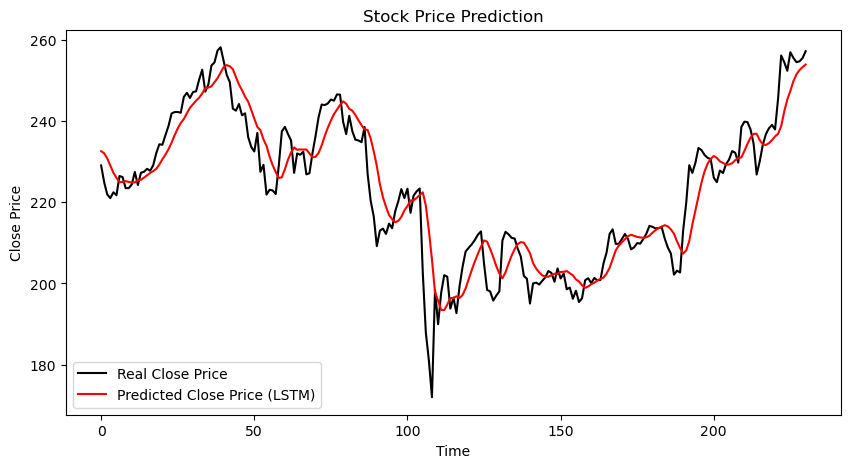

In [71]:
#Plot predictions vs real values

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label='Real Close Price', color='black')
plt.plot(preds_rescaled, label='Predicted Close Price (LSTM)', color='red')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [72]:
# Optional: compare first and last predictions
print("First prediction vs real:", preds_rescaled[0], y_test_rescaled[0])
print("Last prediction vs real:", preds_rescaled[-1], y_test_rescaled[-1])

First prediction vs real: [232.52374] [229.03407]
Last prediction vs real: [253.83363] [257.13]


In [73]:
##GRU 

In [16]:
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])  # take last time step
        return out

model = GRUModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)


In [17]:

    
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss=0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss+= loss.item()
    print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}")



Epoch[1/50], Loss: 0.025434
Epoch[2/50], Loss: 0.049141
Epoch[3/50], Loss: 0.033563
Epoch[4/50], Loss: 0.010435
Epoch[5/50], Loss: 0.005552
Epoch[6/50], Loss: 0.002130
Epoch[7/50], Loss: 0.000804
Epoch[8/50], Loss: 0.000995
Epoch[9/50], Loss: 0.000733
Epoch[10/50], Loss: 0.000686
Epoch[11/50], Loss: 0.000653
Epoch[12/50], Loss: 0.000629
Epoch[13/50], Loss: 0.000625
Epoch[14/50], Loss: 0.000632
Epoch[15/50], Loss: 0.000662
Epoch[16/50], Loss: 0.000722
Epoch[17/50], Loss: 0.000819
Epoch[18/50], Loss: 0.000957
Epoch[19/50], Loss: 0.001135
Epoch[20/50], Loss: 0.001366
Epoch[21/50], Loss: 0.001662
Epoch[22/50], Loss: 0.001951
Epoch[23/50], Loss: 0.002038
Epoch[24/50], Loss: 0.001752
Epoch[25/50], Loss: 0.001204
Epoch[26/50], Loss: 0.000763
Epoch[27/50], Loss: 0.000599
Epoch[28/50], Loss: 0.000602
Epoch[29/50], Loss: 0.000681
Epoch[30/50], Loss: 0.000781
Epoch[31/50], Loss: 0.000862
Epoch[32/50], Loss: 0.000947
Epoch[33/50], Loss: 0.001103
Epoch[34/50], Loss: 0.001342
Epoch[35/50], Loss: 0.0

In [18]:
# Evaluate on train set
model.eval()
train_preds = []
with torch.no_grad():
    for X_batch, _ in train_loader:
        output = model(X_batch)
        train_preds.append(output.detach().numpy())

train_preds = np.vstack(train_preds)
train_preds_rescaled = scaler.inverse_transform(train_preds)
y_train_rescaled = scaler.inverse_transform(torch.from_numpy(Y_train).float())

# Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_rescaled, train_preds_rescaled))
train_mae = mean_absolute_error(y_train_rescaled, train_preds_rescaled)
train_r2 = r2_score(y_train_rescaled, train_preds_rescaled)

print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")

Train RMSE: 6.1745, MAE: 5.6143, R²: 0.9480


In [19]:
# Evaluate GRU on test set

model.eval()  # Set model to evaluation mode
preds = []

with torch.no_grad():  # Disable gradient tracking
    for X_batch, _ in test_loader:
        output = model(X_batch)
        preds.append(output.detach().numpy())

# Combine batch predictions
preds = np.vstack(preds)  # shape -> (num_test_samples, 1)

# Inverse transform (back to original price scale)

preds_rescaled = scaler.inverse_transform(preds)
y_test_rescaled = scaler.inverse_transform(torch.from_numpy(Y_test).float())


In [20]:
#Evaluation Metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_rescaled, preds_rescaled))
mae = mean_absolute_error(y_test_rescaled, preds_rescaled)
r2 = r2_score(y_test_rescaled, preds_rescaled)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")



RMSE: 7.4245
MAE: 6.2452
R²: 0.8421


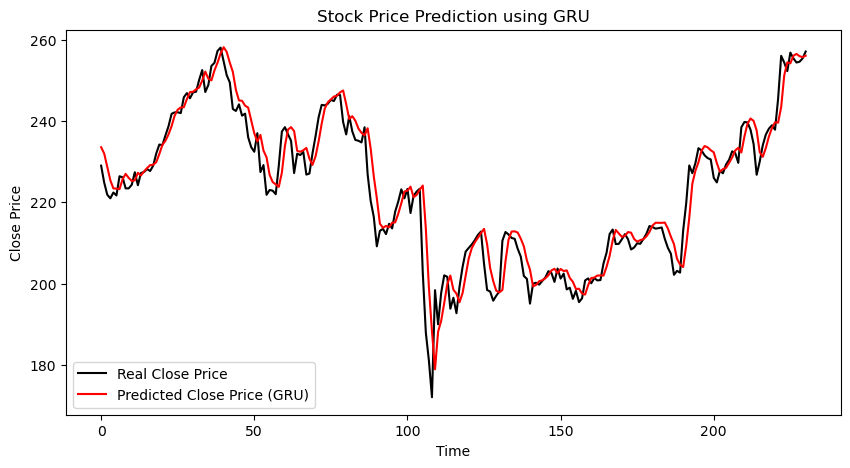

In [79]:
# Plot Predictions vs Real

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label='Real Close Price', color='black')
plt.plot(preds_rescaled, label='Predicted Close Price (GRU)', color='red')
plt.title('Stock Price Prediction using GRU')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [80]:

# Optional: check first/last predictions
print("First prediction vs real:", preds_rescaled[0], y_test_rescaled[0])
print("Last prediction vs real:", preds_rescaled[-1], y_test_rescaled[-1])

First prediction vs real: [233.57028] [229.03407]
Last prediction vs real: [256.10992] [257.13]


In [50]:
#RNN

class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # take last time step
        return out

model = SimpleRNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)



In [51]:

    
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss=0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss+= loss.item()
    print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}")



Epoch[1/50], Loss: 0.058084
Epoch[2/50], Loss: 0.044532
Epoch[3/50], Loss: 0.035618
Epoch[4/50], Loss: 0.020026
Epoch[5/50], Loss: 0.011569
Epoch[6/50], Loss: 0.011183
Epoch[7/50], Loss: 0.007473
Epoch[8/50], Loss: 0.005549
Epoch[9/50], Loss: 0.001278
Epoch[10/50], Loss: 0.001106
Epoch[11/50], Loss: 0.001418
Epoch[12/50], Loss: 0.001800
Epoch[13/50], Loss: 0.002262
Epoch[14/50], Loss: 0.002770
Epoch[15/50], Loss: 0.003226
Epoch[16/50], Loss: 0.003500
Epoch[17/50], Loss: 0.003520
Epoch[18/50], Loss: 0.003348
Epoch[19/50], Loss: 0.003128
Epoch[20/50], Loss: 0.002963
Epoch[21/50], Loss: 0.002887
Epoch[22/50], Loss: 0.002889
Epoch[23/50], Loss: 0.002939
Epoch[24/50], Loss: 0.003002
Epoch[25/50], Loss: 0.003049
Epoch[26/50], Loss: 0.003061
Epoch[27/50], Loss: 0.003038
Epoch[28/50], Loss: 0.002991
Epoch[29/50], Loss: 0.002937
Epoch[30/50], Loss: 0.002890
Epoch[31/50], Loss: 0.002854
Epoch[32/50], Loss: 0.002829
Epoch[33/50], Loss: 0.002810
Epoch[34/50], Loss: 0.002792
Epoch[35/50], Loss: 0.0

In [52]:
# Train Set Predictions & Metrics

model.eval()
train_preds = []
with torch.no_grad():
    for X_batch, _ in train_loader:
        output = model(X_batch)
        train_preds.append(output.detach().numpy())

train_preds = np.vstack(train_preds)
train_preds_rescaled = scaler.inverse_transform(train_preds)
y_train_rescaled = scaler.inverse_transform(torch.from_numpy(Y_train).float())
train_rmse = np.sqrt(mean_squared_error(y_train_rescaled, train_preds_rescaled))
train_mae = mean_absolute_error(y_train_rescaled, train_preds_rescaled)
train_r2 = r2_score(y_train_rescaled, train_preds_rescaled)
print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")

Train RMSE: 9.6362, MAE: 8.8071, R²: 0.8734


In [53]:
# Test Set Predictions & Metrics

model.eval()  # Set model to evaluation mode
preds = []

with torch.no_grad():  # Disable gradient tracking
    for X_batch, _ in test_loader:
        output = model(X_batch)
        preds.append(output.detach().numpy())

# Combine batch predictions
preds = np.vstack(preds)  # shape -> (num_test_samples, 1)

# Inverse transform (back to original price scale)

preds_rescaled = scaler.inverse_transform(preds)
y_test_rescaled = scaler.inverse_transform(torch.from_numpy(Y_test).float())

In [54]:
#Evaluation Metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_rescaled, preds_rescaled))
mae = mean_absolute_error(y_test_rescaled, preds_rescaled)
r2 = r2_score(y_test_rescaled, preds_rescaled)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")



RMSE: 6.0041
MAE: 4.5958
R²: 0.8967


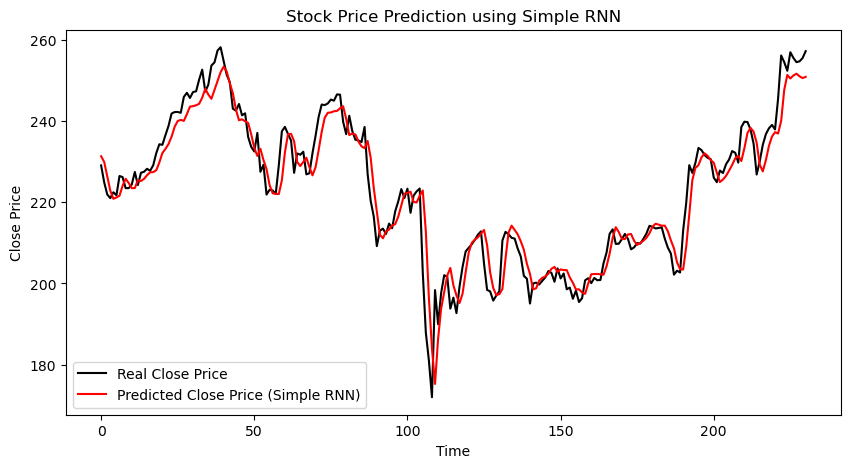

In [86]:
# Plot Predictions vs Real

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_rescaled, label='Real Close Price', color='black')
plt.plot(preds_rescaled, label='Predicted Close Price (Simple RNN)', color='red')
plt.title('Stock Price Prediction using Simple RNN')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [87]:

# Optional: check first/last predictions
print("First prediction vs real:", preds_rescaled[0], y_test_rescaled[0])
print("Last prediction vs real:", preds_rescaled[-1], y_test_rescaled[-1])

First prediction vs real: [231.2839] [229.03407]
Last prediction vs real: [250.81602] [257.13]


In [ ]:
#manyy -to- many GRU

In [22]:
split_idx = int(0.8 * len(df_pd))
train_df = df_pd.iloc[:split_idx]
test_df = df_pd.iloc[split_idx:]


In [23]:
scaler = MinMaxScaler(feature_range=(-1,1))
train_scaled = scaler.fit_transform(train_df[['Close']].values)  # fit only on training data
test_scaled = scaler.transform(test_df[['Close']].values)        # transform test using same scaler

# Concatenate for sequence creation
data_scaled = np.concatenate([train_scaled, test_scaled])


In [24]:
def create_sequences(data, input_window=40, output_window=10):
    X, y = [], []
    for i in range(input_window, len(data)-output_window+1):
        X.append(data[i-input_window:i])
        y.append(data[i:i+output_window])
    return np.array(X), np.array(y)

input_window = 40
output_window = 10
X, y = create_sequences(data_scaled, input_window, output_window)

print("X shape:", X.shape, "y shape:", y.shape)
# X -> (num_samples, 40, 1), y -> (num_samples, 10, 1)


X shape: (1649, 40, 1) y shape: (1649, 10, 1)


In [25]:
X_tensor = torch.tensor(X, dtype=torch.float32)  # (samples, timesteps, features)
y_tensor = torch.tensor(y, dtype=torch.float32).squeeze(-1)  # remove last dimension
              # (samples, output_window)

split_seq = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split_seq], X_tensor[split_seq:]
y_train, y_test = y_tensor[:split_seq], y_tensor[split_seq:]

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [27]:
class UniGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_window=10):
        super(UniGRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_window)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

class BiGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_window=10):
        super(BiGRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, output_window)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


In [28]:
def train_model(model, optimizer, train_loader, epochs=30):
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss/len(train_loader):.6f}")


In [29]:
# Uni-GRU
model_uni = UniGRUModel(input_size=1, hidden_size=50, num_layers=2, output_window=output_window)
optimizer_uni = torch.optim.Adam(model_uni.parameters(), lr=0.001)
train_model(model_uni, optimizer_uni, train_loader, epochs=30)

# Bi-GRU
model_bi = BiGRUModel(input_size=1, hidden_size=50, num_layers=2, output_window=output_window)
optimizer_bi = torch.optim.Adam(model_bi.parameters(), lr=0.001)
train_model(model_bi, optimizer_bi, train_loader, epochs=30)


Epoch [1/30], Avg Loss: 0.261546
Epoch [2/30], Avg Loss: 0.208178
Epoch [3/30], Avg Loss: 0.015565
Epoch [4/30], Avg Loss: 0.013664
Epoch [5/30], Avg Loss: 0.014815
Epoch [6/30], Avg Loss: 0.012466
Epoch [7/30], Avg Loss: 0.013593
Epoch [8/30], Avg Loss: 0.012733
Epoch [9/30], Avg Loss: 0.013454
Epoch [10/30], Avg Loss: 0.012878
Epoch [11/30], Avg Loss: 0.013358
Epoch [12/30], Avg Loss: 0.012846
Epoch [13/30], Avg Loss: 0.013084
Epoch [14/30], Avg Loss: 0.012589
Epoch [15/30], Avg Loss: 0.012624
Epoch [16/30], Avg Loss: 0.012154
Epoch [17/30], Avg Loss: 0.012050
Epoch [18/30], Avg Loss: 0.011624
Epoch [19/30], Avg Loss: 0.011443
Epoch [20/30], Avg Loss: 0.011074
Epoch [21/30], Avg Loss: 0.010864
Epoch [22/30], Avg Loss: 0.010552
Epoch [23/30], Avg Loss: 0.010343
Epoch [24/30], Avg Loss: 0.010083
Epoch [25/30], Avg Loss: 0.009888
Epoch [26/30], Avg Loss: 0.009672
Epoch [27/30], Avg Loss: 0.009497
Epoch [28/30], Avg Loss: 0.009316
Epoch [29/30], Avg Loss: 0.009160
Epoch [30/30], Avg Loss

In [30]:
def evaluate_metrics(model, loader, scaler, y_true):
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            output = model(X_batch)
            preds.append(output.detach().numpy())
    preds = np.vstack(preds)
    
    # Rescale back to original prices
    preds_rescaled = scaler.inverse_transform(preds)
    y_rescaled = scaler.inverse_transform(y_true.numpy())
    
    rmse = np.sqrt(mean_squared_error(y_rescaled, preds_rescaled))
    mae = mean_absolute_error(y_rescaled, preds_rescaled)
    r2 = r2_score(y_rescaled, preds_rescaled)
    return preds_rescaled, y_rescaled, rmse, mae, r2


In [31]:
# Uni-GRU
pred_train_uni, y_train_rescaled_uni, rmse_train_uni, mae_train_uni, r2_train_uni = evaluate_metrics(model_uni, train_loader, scaler, y_train)
pred_test_uni, y_test_rescaled_uni, rmse_test_uni, mae_test_uni, r2_test_uni = evaluate_metrics(model_uni, test_loader, scaler, y_test)

print("Uni-GRU Training -> RMSE:", rmse_train_uni, "MAE:", mae_train_uni, "R2:", r2_train_uni)
print("Uni-GRU Testing  -> RMSE:", rmse_test_uni, "MAE:", mae_test_uni, "R2:", r2_test_uni)

# Bi-GRU
pred_train_bi, y_train_rescaled_bi, rmse_train_bi, mae_train_bi, r2_train_bi = evaluate_metrics(model_bi, train_loader, scaler, y_train)
pred_test_bi, y_test_rescaled_bi, rmse_test_bi, mae_test_bi, r2_test_bi = evaluate_metrics(model_bi, test_loader, scaler, y_test)

print("Bi-GRU Training -> RMSE:", rmse_train_bi, "MAE:", mae_train_bi, "R2:", r2_train_bi)
print("Bi-GRU Testing  -> RMSE:", rmse_test_bi, "MAE:", mae_test_bi, "R2:", r2_test_bi)


Uni-GRU Training -> RMSE: 6.504395 MAE: 5.206411 R2: 0.9793733300033296
Uni-GRU Testing  -> RMSE: 11.221265 MAE: 8.735733 R2: 0.4830778846231262
Bi-GRU Training -> RMSE: 6.1895466 MAE: 4.868534 R2: 0.9813206791553093
Bi-GRU Testing  -> RMSE: 9.601866 MAE: 7.1022806 R2: 0.6216839490475405
